In [1]:
import os
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

In [4]:
EXCEL_PATH = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\dataset_summary_for_post_processing_manually_checked.xlsx"
OUTPUT_EXCEL = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\dataset_summary_for_post_processing_manually_checked2.xlsx"
INPUT_DIR = r"C:\Users\KostasPikounis\OneDrive_Inlecom_Personal\OneDrive - INLECOM\Amfitrite\task2\IWD\data"


Reviewing UID: 1335_2019-11-03
Original Class: Low
Old Stats -> Water: 123256 | High: 0 | Mod: 25 | Low: 1237
NEW Stats -> Water: 65488 | High: 0 | Mod: 14 | Low: 660
--------------------------------------------------


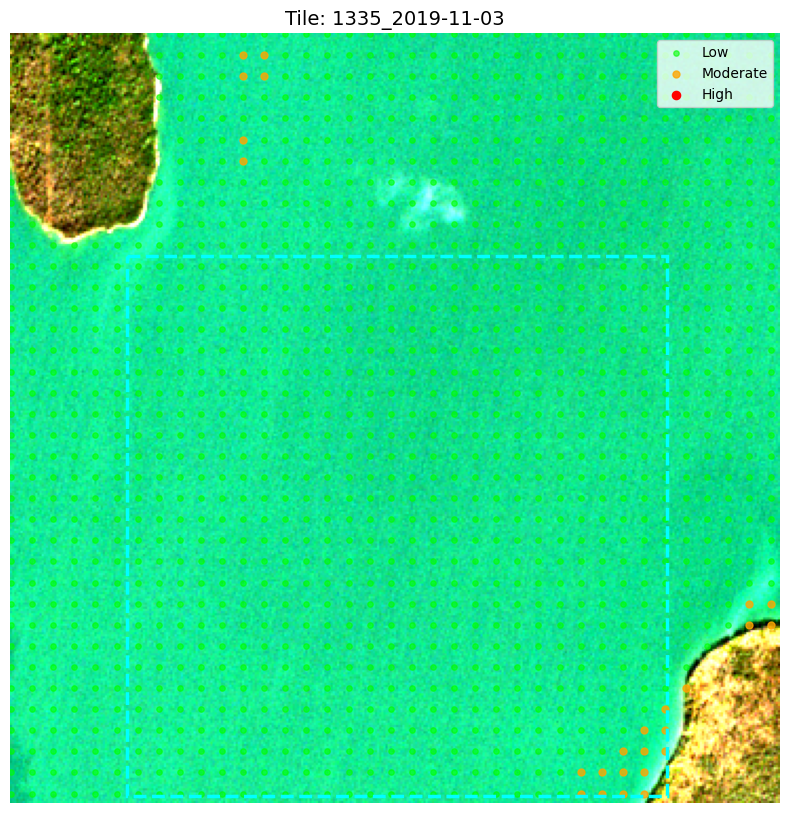

Press Enter to keep 'Low', or type new class (e.g., High, Moderate, Low):  


Saved class 'Low' and updated excel.


Continue to next image? (y/n) [default: y]:  


In [5]:
def normalize_rgb(arr):
    """Robustly normalizes an image array using percentile stretching."""
    arr = arr.astype(float)
    
    # We calculate percentiles ignoring pure zero (no-data) pixels
    valid_pixels = arr[arr > 0]
    
    if len(valid_pixels) == 0:
        return np.zeros_like(arr) # Return black if image is completely empty

    # Find the 2nd and 98th percentile brightness values
    p2, p98 = np.percentile(valid_pixels, (2, 98))
    
    # Prevent division by zero if an image is completely uniform
    if p98 == p2:
        return np.clip(arr / (np.max(arr) + 1e-5), 0, 1)
    
    # Stretch the contrast
    arr_norm = (arr - p2) / (p98 - p2)
    
    # Ensure all values are strictly between 0 and 1 for matplotlib
    return np.clip(arr_norm, 0, 1)

def visualize_tile(folder_name, crop_r, crop_c):
    """Reconstructs the image, plots CyFi points, and draws the crop box."""
    folder_path = os.path.join(INPUT_DIR, folder_name)
    visual_path = os.path.join(folder_path, "visual_raw.tif")
    cyfi_path = os.path.join(folder_path, "cyfi_lattice_predictions.csv")
    
    if not os.path.exists(visual_path):
        print(f"Error: {visual_path} not found.")
        return

    # Load True Color Image
    with rasterio.open(visual_path) as src:
        # Read the 3 RGB bands (usually B04, B03, B02 in visual_raw)
        rgb = src.read([1, 2, 3])
        # Rasterio reads as (bands, height, width). Matplotlib needs (height, width, bands)
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = normalize_rgb(rgb)

    # Setup Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(rgb)
    ax.set_title(f"Tile: {folder_name}", fontsize=14)

    # Plot CyFi Points
    if os.path.exists(cyfi_path):
        df_cyfi = pd.read_csv(cyfi_path)
        
        # Filter by severity and plot
        high_mask = df_cyfi['severity'].str.lower() == 'high'
        mod_mask = df_cyfi['severity'].str.lower() == 'moderate'
        low_mask = df_cyfi['severity'].str.lower() == 'low'
        
        # Note: Matplotlib scatter expects (x, y), which maps to (col, row)
        ax.scatter(df_cyfi[low_mask]['pixel_col'], df_cyfi[low_mask]['pixel_row'], 
                   c='lime', s=15, alpha=0.6, label='Low')
        ax.scatter(df_cyfi[mod_mask]['pixel_col'], df_cyfi[mod_mask]['pixel_row'], 
                   c='orange', s=25, alpha=0.8, label='Moderate')
        ax.scatter(df_cyfi[high_mask]['pixel_col'], df_cyfi[high_mask]['pixel_row'], 
                   c='red', s=35, alpha=1.0, label='High')
        
        ax.legend(loc='upper right')

    # Draw the Crop Bounding Box
    if pd.notna(crop_r) and pd.notna(crop_c):
        # Rectangle takes (x, y) which is (col, row)
        rect = patches.Rectangle((crop_c, crop_r), 256, 256, linewidth=2.5, edgecolor='cyan', facecolor='none', linestyle='--')
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

def run_interactive_review():
    # Load DataFrame
    load_path = OUTPUT_EXCEL if os.path.exists(OUTPUT_EXCEL) else EXCEL_PATH
    df = pd.read_excel(load_path)
    
    # Ensure columns exist
    for col in ['to_be_checked', 'visualized', 'new_indicative_class']:
        if col not in df.columns:
            df[col] = 0 if col != 'new_indicative_class' else None

    # --- Phase 1: Contextual Visualization ---
    print("--- Context Calibration ---")
    try:
        n_high = int(input("How many typical 'High' HAB images do you want to see? (0 to skip): ") or 0)
        n_mod = int(input("How many typical 'Moderate' images do you want to see? (0 to skip): ") or 0)
        n_low = int(input("How many typical 'Low/non-HAB' images do you want to see? (0 to skip): ") or 0)
    except ValueError:
        print("Invalid input. Skipping context phase.")
        n_high, n_mod, n_low = 0, 0, 0

    def show_random_examples(severity, count):
        if count <= 0: return
        # Filter for normal examples (not marked for checking)
        mask = (df['indicative_class'].str.lower() == severity.lower()) & (df['to_be_checked'] != 1)
        samples = df[mask].sample(min(count, mask.sum()))
        
        for _, row in samples.iterrows():
            clear_output(wait=True)
            print(f"--- Example of typical '{severity.capitalize()}' class ---")
            folder_name = next((d for d in os.listdir(INPUT_DIR) if d.startswith(str(row['uid']))), None)
            if folder_name:
                visualize_tile(folder_name, row['crop_row'], row['crop_col'])
            input("Press Enter to see the next example...")

    show_random_examples('high', n_high)
    show_random_examples('moderate', n_mod)
    show_random_examples('low', n_low)

    # --- Phase 2: Manual Review ---
    clear_output(wait=True)
    print("--- Starting Manual Review Phase ---")
    
    # Filter items that need checking and haven't been visualized yet
    to_check = df[(df['to_be_checked'] == 1) & (df['visualized'] != 1)]
    
    if to_check.empty:
        print("No remaining images to check! You are all done.")
        return

    for idx, row in to_check.iterrows():
        clear_output(wait=True)
        folder_name = next((d for d in os.listdir(INPUT_DIR) if d.startswith(str(row['uid']))), None)
        
        if not folder_name:
            print(f"Warning: Folder for UID {row['uid']} not found. Skipping.")
            continue
            
        print(f"Reviewing UID: {row['uid']}")
        print(f"Original Class: {row['indicative_class']}")
        print(f"Old Stats -> Water: {row['water_pixels']} | High: {row['high_pred']} | Mod: {row['mod_pred']} | Low: {row['low_pred']}")
        print(f"NEW Stats -> Water: {row['new_water_pixels']} | High: {row['new_high_pred']} | Mod: {row['new_mod_pred']} | Low: {row['new_low_pred']}")
        print("-" * 50)
        
        visualize_tile(folder_name, row['crop_row'], row['crop_col'])
        
        # Get user input for classification
        user_input = input(f"Press Enter to keep '{row['indicative_class']}', or type new class (e.g., High, Moderate, Low): ").strip()
        
        if user_input == "":
            final_class = str(row['indicative_class']).capitalize()
        else:
            final_class = user_input.capitalize()
            
        # Update DataFrame
        df.at[idx, 'new_indicative_class'] = final_class
        df.at[idx, 'visualized'] = 1
        
        # Save progress immediately
        df.to_excel(OUTPUT_EXCEL, index=False)
        print(f"Saved class '{final_class}' and updated excel.")
        
        # Ask to continue
        cont = input("Continue to next image? (y/n) [default: y]: ").strip().lower()
        if cont == 'n' or cont == 'no':
            print("Stopping review process. Progress has been saved.")
            break

# Run the tool
run_interactive_review()

